- 2021.11.19  u.k.  plotting of absorption profile

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


In [3]:
import os

import numpy as np

#%matplotlib inline
#%matplotlib qt
import matplotlib.pyplot as plt
#from matplotlib.colors import LogNorm


In [4]:
%load_ext autoreload
%autoreload 2

from spectra.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

In [5]:
from spectra.Struct import Atom
from spectra.Util import HelpUtil

---

In [6]:
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H.conf" )
atom, path_dict = Atom.init_Atom_(conf_path , is_hydrogen=True)

In [7]:
from spectra.Util import MeshUtil

# common wavelength mesh in unit of Doppler width
pars = {
    "num_mesh" : 101,
    "qcore"    : 2.5,
    "qwing"    : 10.,
}

mesh = MeshUtil.make_full_line_mesh_(pars["num_mesh"], pars["qcore"], pars["qwing"])
mesh.shape

(101,)

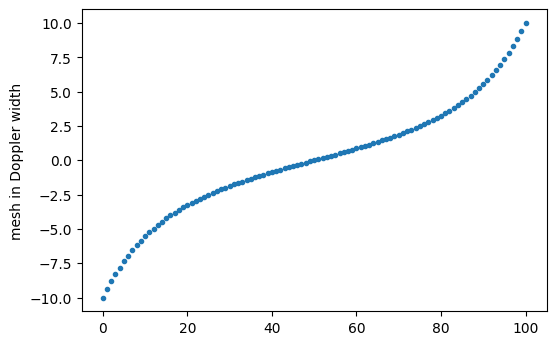

In [15]:
fig, ax = plt.subplots(1,1, figsize=(6,4),dpi=100)
ax.plot(mesh, "o", markersize=3)
ax.set_ylabel("mesh in Doppler width")
plt.show()

In [21]:
# parameters to calculate Doppler width
Te = 8E3  # [K]
Vt = 5E5  # [cm/s]

# line index 
kl = {
    "Ha" : 7,
    "Hb" : 8,
    "Hr" : 9,
}

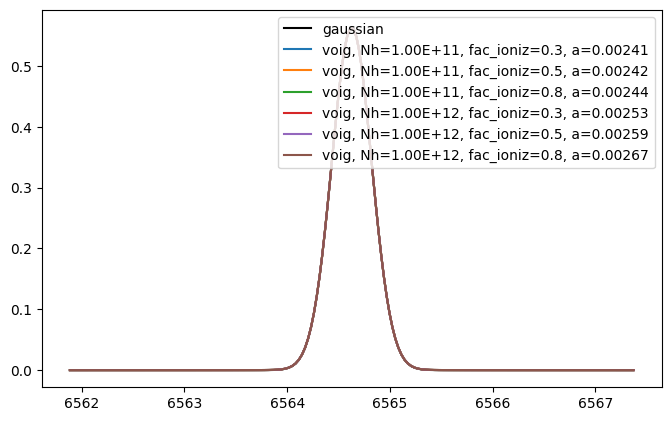

In [54]:
from spectra.RadiativeTransfer import Profile
from spectra.Atomic import BasicP
from spectra.Atomic import Hydrogen

name = "Ha"
k = kl[name]
# Doppler width
w0 = atom.Line["w0"][k]
f0 = atom.Line["f0"][k]
Aji = atom.Line["AJI"][k]
dop_width_cm = BasicP.doppler_width_(w0, Te, Vt, atom.Mass)
dop_width_hz = BasicP.doppler_width_(f0, Te, Vt, atom.Mass)

# wavelength mesh in [cm]
mesh_AA = (dop_width_cm * mesh[:] + w0) * 1E8

# gaussian profile
prof_g = Profile.gaussian_(mesh)

# voigt profile
prof_v = {}

for Nh in (1E11, 1E12):
    for fac_ioniz in (0.3, 0.5, 0.8):
        Ne          = Nh * fac_ioniz
        Nh_I_ground = Nh * (1-fac_ioniz)
        gamma = atom.Line["Gamma"][k]
        gamma += Hydrogen.collisional_broadening_Res_and_Van_(atom.Line["ni"][k], atom.Line["nj"][k], Nh_I_ground, Te)
        gamma += Hydrogen.collisional_broadening_LinearStark_(atom.Line["ni"][k], atom.Line["nj"][k], Ne)
        a = gamma / ( 4. * CST.pi_ * dop_width_hz )
        prof_v[f"Nh={Nh:1.2E}, fac_ioniz={fac_ioniz:.1f}, a={a:.5f}"] = Profile.voigt_(a, mesh)

# plots
fig, ax = plt.subplots(1,1, figsize=(8,5), dpi=100)
ax.plot(mesh_AA, prof_g, "k-", label="gaussian")
for key, prof in prof_v.items():
    ax.plot(mesh_AA, prof, "-", label=f"voig, {key}")
ax.legend(loc="upper right")
plt.show()